In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, 
                           recall_score, f1_score, 
                           classification_report, confusion_matrix)
%matplotlib inline
sns.set_style("whitegrid")


In [7]:
df = pd.read_csv("Crop_recommendation.csv")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print("\nCrop distribution:\n", df['label'].value_counts().head())
df.head()


Shape: (2200, 8)
Columns: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']

Crop distribution:
 label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
Name: count, dtype: int64


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


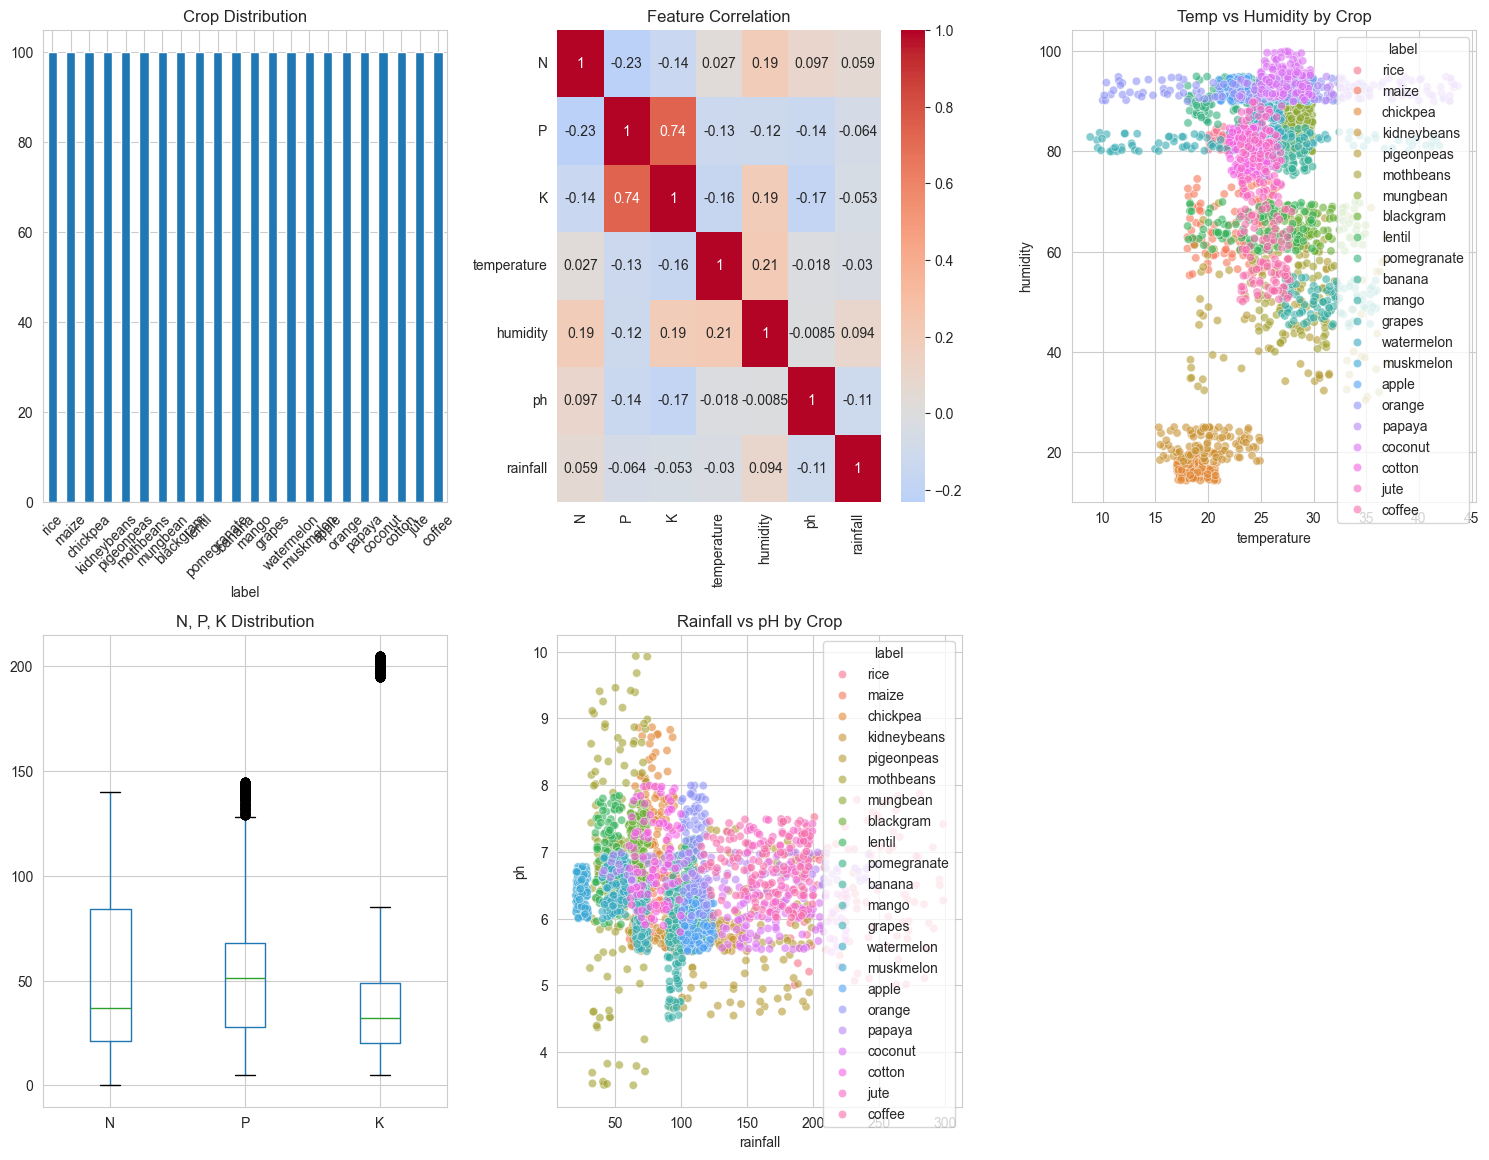

In [8]:
plt.figure(figsize=(15, 12))

plt.subplot(2, 3, 1)
df['label'].value_counts().plot(kind='bar')
plt.title('Crop Distribution')
plt.xticks(rotation=45)

plt.subplot(2, 3, 2)
corr = df.drop('label', axis=1).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation')

plt.subplot(2, 3, 3)
sns.scatterplot(data=df, x='temperature', y='humidity', hue='label', alpha=0.6)
plt.title('Temp vs Humidity by Crop')

plt.subplot(2, 3, 4)
df[['N', 'P', 'K']].boxplot()
plt.title('N, P, K Distribution')

plt.subplot(2, 3, 5)
sns.scatterplot(data=df, x='rainfall', y='ph', hue='label', alpha=0.6)
plt.title('Rainfall vs pH by Crop')

plt.tight_layout()
plt.show()


In [9]:
X = df.drop('label', axis=1)
y = df['label']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f"Features shape: {X.shape}")
print(f"Classes: {le.classes_}")


Features shape: (2200, 7)
Classes: ['apple' 'banana' 'blackgram' 'chickpea' 'coconut' 'coffee' 'cotton'
 'grapes' 'jute' 'kidneybeans' 'lentil' 'maize' 'mango' 'mothbeans'
 'mungbean' 'muskmelon' 'orange' 'papaya' 'pigeonpeas' 'pomegranate'
 'rice' 'watermelon']


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")


Train: (1760, 7), Test: (440, 7)


In [11]:
clf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)
print("✅ Model trained!")


✅ Model trained!


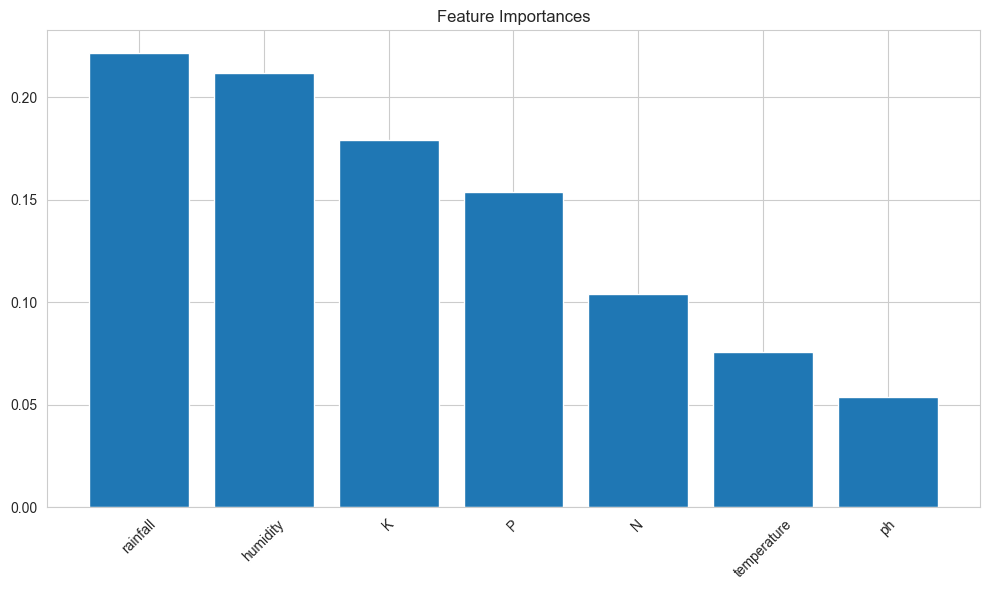

In [12]:
importances = clf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importances")
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), X.columns[indices], rotation=45)
plt.tight_layout()
plt.show()


In [13]:
# Train metrics
y_train_pred = clf.predict(X_train)
train_acc = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred, average='weighted')
train_recall = recall_score(y_train, y_train_pred, average='weighted')
train_f1 = f1_score(y_train, y_train_pred, average='weighted')

# Test metrics
y_test_pred = clf.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, average='weighted')
test_recall = recall_score(y_test, y_test_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')

# Results table
metrics = pd.DataFrame({
    'Dataset': ['Train', 'Test'],
    'Accuracy': [train_acc, test_acc],
    'Precision': [train_precision, test_precision],
    'Recall': [train_recall, test_recall],
    'F1-Score': [train_f1, test_f1]
})
print("📊 Model Performance:")
print(metrics.round(4))


📊 Model Performance:
  Dataset  Accuracy  Precision  Recall  F1-Score
0   Train    1.0000     1.0000  1.0000    1.0000
1    Test    0.9932     0.9935  0.9932    0.9932


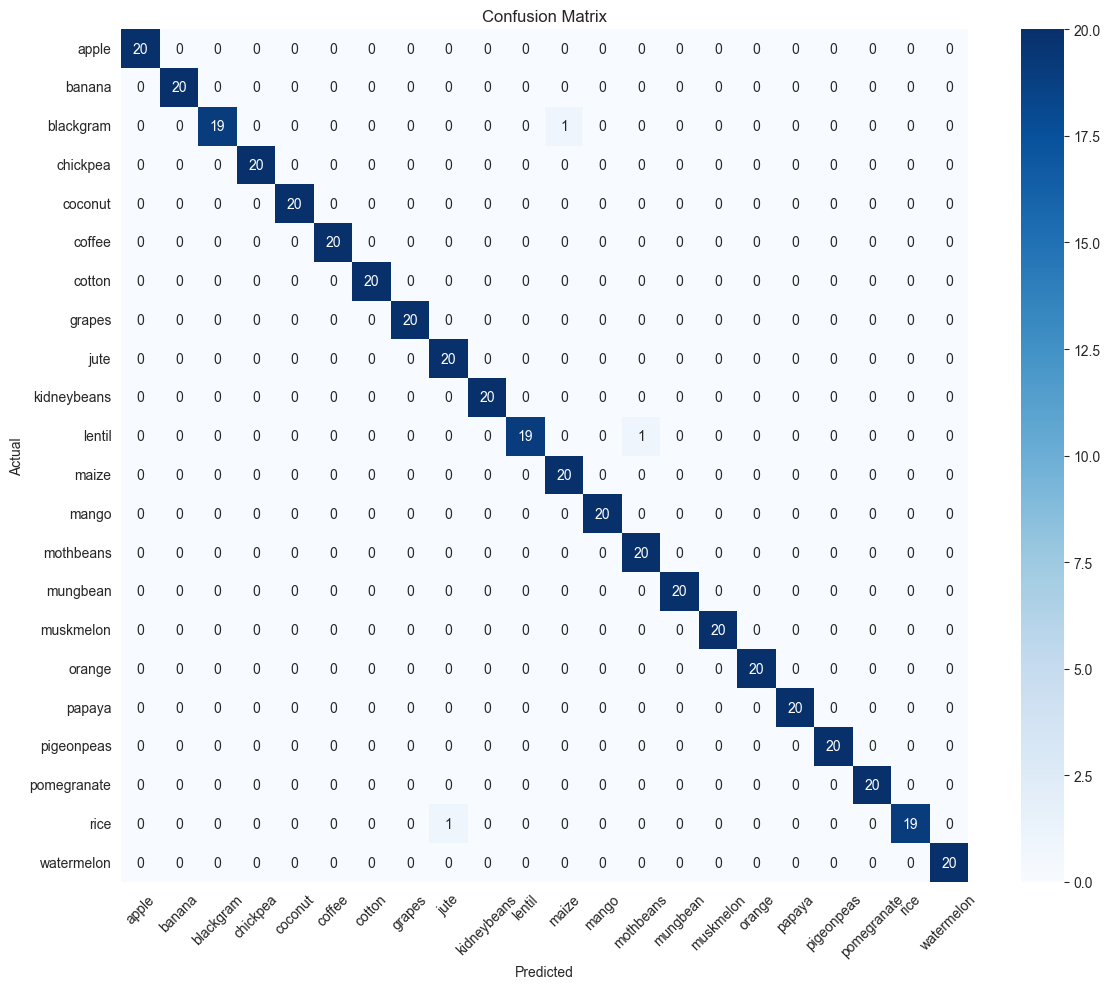

📋 Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      0.95      0.97        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.95      1.00      0.98        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00        20
  

In [14]:
plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("📋 Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=le.classes_))


In [15]:
import joblib
joblib.dump(clf, 'crop_model.pkl')
joblib.dump(le, 'label_encoder.pkl')
print("✅ Model & encoder saved!")


✅ Model & encoder saved!
